# Econ 421 Research Project

In [2]:
""" 

Day 1 — Data
1. Load dataset 
2. Explore: shape, dtypes, missing values
3. Descriptive stats table
4. Correlation matrix + heatmap
5. Default rate distribution plot

Day 2 — Econometric Models
6. LPM via OLS (statsmodels)
7. Logit (statsmodels)
8. Probit (statsmodels)
9. Marginal effects at the mean

Day 3 — Model Evaluation
10. AIC/BIC/LR test table
11. McFadden Pseudo R²
12. ROC curve + AUC (all models)
13. Confusion matrix

Day 4 — ML Section
14. Train/test split (80/20)
15. Random Forest (sklearn)
16. Feature importance plot
17. Compare AUC: Logit vs Probit vs RF

Day 5 — Paper
18. Write all sections
19. Polish tables and figures
20. Appendix + references


Data: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
"""

' \n\nDay 1 — Data\n1. Load dataset \n2. Explore: shape, dtypes, missing values\n3. Descriptive stats table\n4. Correlation matrix + heatmap\n5. Default rate distribution plot\n\nDay 2 — Econometric Models\n6. LPM via OLS (statsmodels)\n7. Logit (statsmodels)\n8. Probit (statsmodels)\n9. Marginal effects at the mean\n\nDay 3 — Model Evaluation\n10. AIC/BIC/LR test table\n11. McFadden Pseudo R²\n12. ROC curve + AUC (all models)\n13. Confusion matrix\n\nDay 4 — ML Section\n14. Train/test split (80/20)\n15. Random Forest (sklearn)\n16. Feature importance plot\n17. Compare AUC: Logit vs Probit vs RF\n\nDay 5 — Paper\n18. Write all sections\n19. Polish tables and figures\n20. Appendix + references\n\n\nData: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients\n'

This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. 

This study reviewed the literature and used the following 23 variables as explanatory variables:
- X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
- X2: Gender (1 = male; 2 = female).
- X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
- X4: Marital status (1 = married; 2 = single; 3 = others).
- X5: Age (year).

- X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

- X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005. 

- X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

### Libraries

In [3]:
# Data manipulation
import pandas as pd 
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.edgecolor": "#cccccc",
    "axes.facecolor": "#f9f9f9",     # Light grey panel background
    "figure.facecolor": "white",     # White figure background
    "grid.color": "#dcdcdc",         # Subtle gridlines
    "grid.alpha": 0.6,
    "legend.facecolor": "white",     # White legend background
    "legend.edgecolor": "#dddddd",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Machine learning and deep learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Miscellaneous
import os 
import warnings
warnings.filterwarnings('ignore')

# Time and date handling
import datetime as dt
import time 

# Statistical modeling (logit & probit)
import statsmodels.api as sm
import math
import scipy.stats as stats
import scipy


In [4]:
# Dataset access (uncomment if you need to install the package)
#   pip install ucimlrepo 

In [5]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
x = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 


In [6]:
# metadata 
print(default_of_credit_card_clients.metadata) 

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [7]:
# variable information 
print(default_of_credit_card_clients.variables) 

   name     role     type      demographic                 description units  \
0    ID       ID  Integer             None                        None  None   
1    X1  Feature  Integer             None                   LIMIT_BAL  None   
2    X2  Feature  Integer              Sex                         SEX  None   
3    X3  Feature  Integer  Education Level                   EDUCATION  None   
4    X4  Feature  Integer   Marital Status                    MARRIAGE  None   
5    X5  Feature  Integer              Age                         AGE  None   
6    X6  Feature  Integer             None                       PAY_0  None   
7    X7  Feature  Integer             None                       PAY_2  None   
8    X8  Feature  Integer             None                       PAY_3  None   
9    X9  Feature  Integer             None                       PAY_4  None   
10  X10  Feature  Integer             None                       PAY_5  None   
11  X11  Feature  Integer             No

### Data analysis

In [8]:
# Data analysis
# No missing values, all variables are numeric, 23 features + 1 binary target variable (default payment next month)

# features descriptions
feature_names = default_of_credit_card_clients.variables['description']
feature_names.iloc[0] = "ID" # Rename the first feature for clarity
x.columns = feature_names.iloc[1:24] # set feature names as column headers in the dataframe

In [9]:
x['EDUCATION'] = x['EDUCATION'].replace({0:4, 5:4, 6:4}) # Recode invalid education values to '4' (others) based on dataset documentation
x['MARRIAGE'] = x['MARRIAGE'].replace({0:3}) # Recode invalid marriage value to '3' (others) based on dataset documentation

In [10]:
# Create a combined dataframe for easier analysis
df = x.copy()
df['default'] = y.values

In [11]:
# Explore the dataset
x.describe().transpose().iloc[:, 1:8]
# 30000 entries, 6 bills + 6 payments

,mean,std,min,25%,50%,75%,max
description,,,,,,,
LIMIT_BAL,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
MARRIAGE,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
AGE,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


#

In [12]:
print(x.head(2).transpose()) # Transpose for better readability
print(x.shape) # (30000, 23)

                 0       1
description               
LIMIT_BAL    20000  120000
SEX              2       2
EDUCATION        2       2
MARRIAGE         1       2
AGE             24      26
PAY_0            2      -1
PAY_2            2       2
PAY_3           -1       0
PAY_4           -1       0
PAY_5           -2       0
PAY_6           -2       2
BILL_AMT1     3913    2682
BILL_AMT2     3102    1725
BILL_AMT3      689    2682
BILL_AMT4        0    3272
BILL_AMT5        0    3455
BILL_AMT6        0    3261
PAY_AMT1         0       0
PAY_AMT2       689    1000
PAY_AMT3         0    1000
PAY_AMT4         0    1000
PAY_AMT5         0       0
PAY_AMT6         0    2000
(30000, 23)


<Axes: xlabel='description', ylabel='description'>

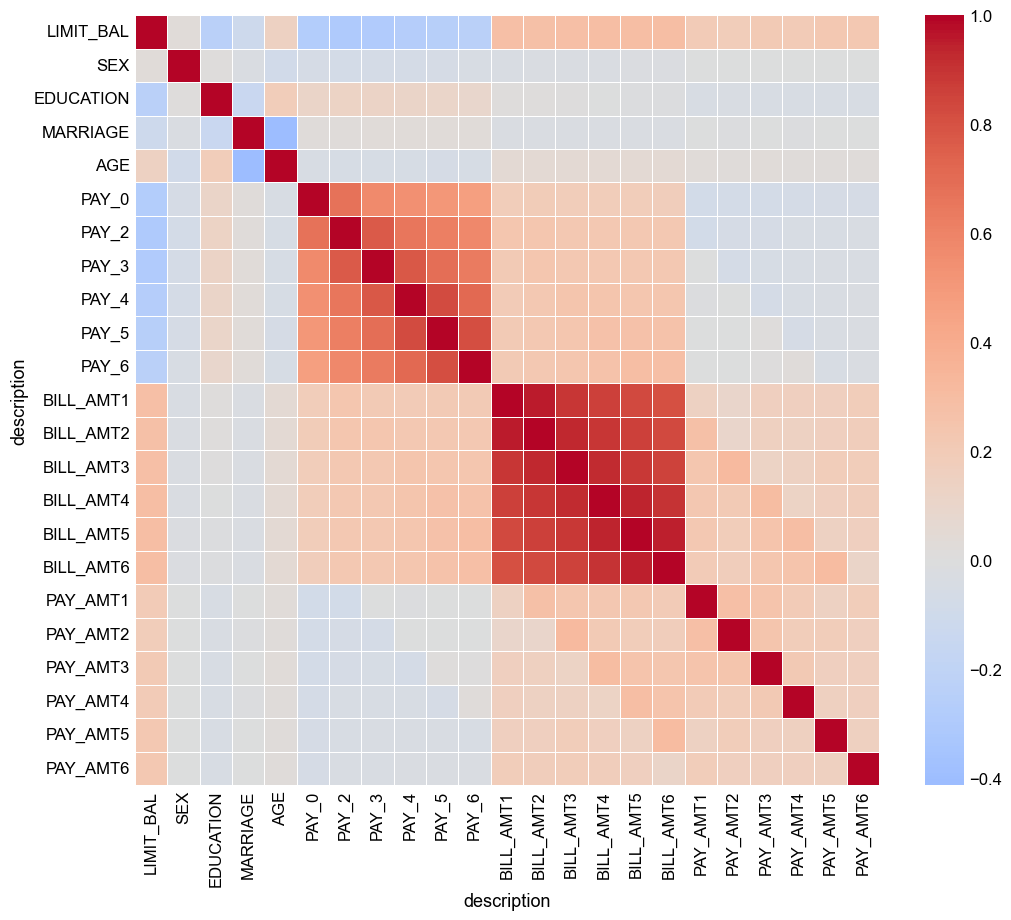

In [13]:
# correlation matrix and heatmap
corr_matrix = x.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5, annot=False)

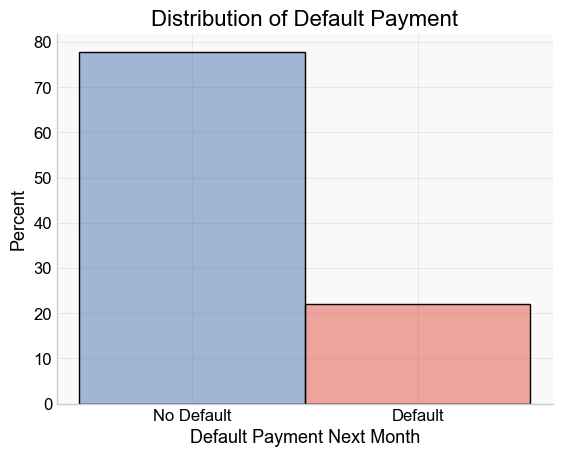

In [14]:
# Distribution of default payment
sns.histplot(data=df, x='default', stat='percent', bins=2, color='#4c72b0', edgecolor='black', hue='default', palette={0: '#4c72b0', 1: "#e64e43"}, legend=False)
plt.xticks((0.25, 0.75), ['No Default', 'Default'])
plt.title("Distribution of Default Payment")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Percent")
plt.show()

# 80% of clients do not default, 20% do default

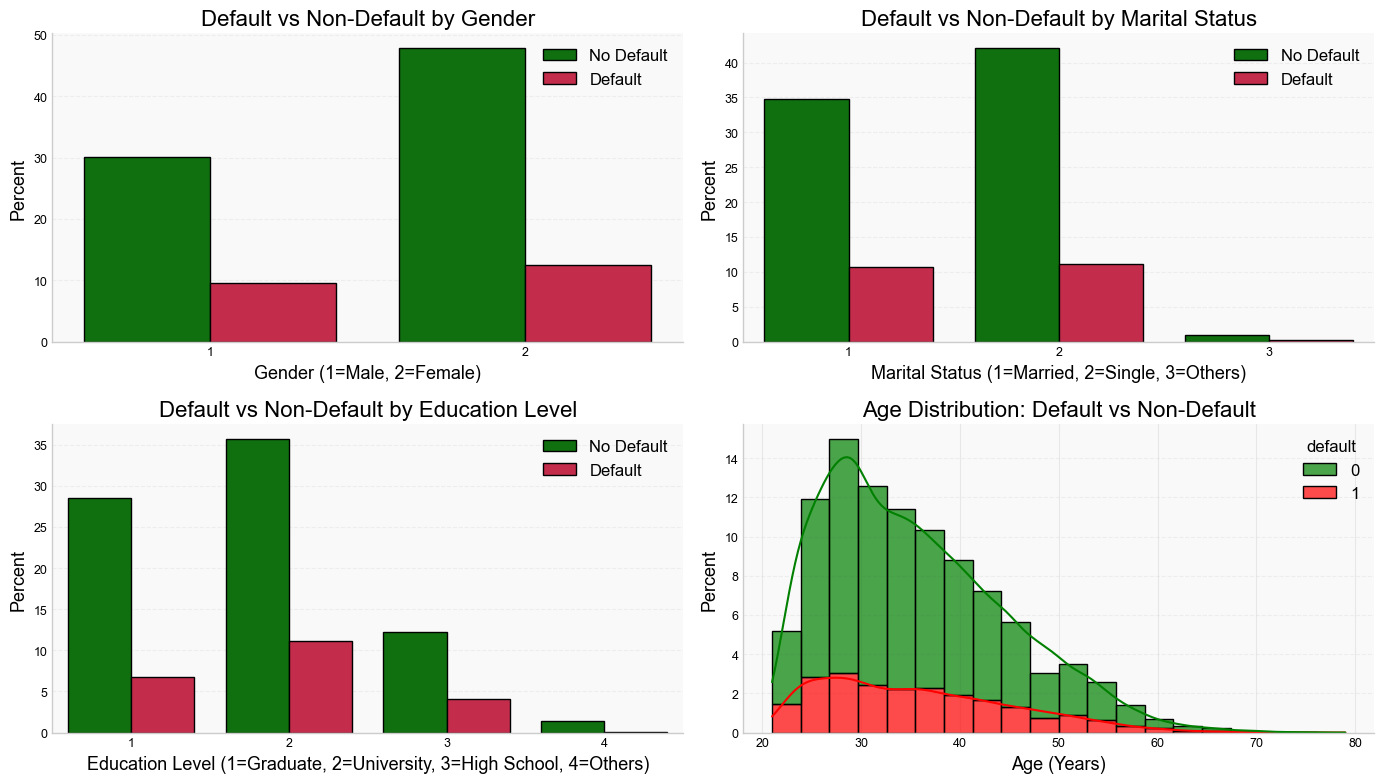

In [15]:
# distribution of key categorical features
fig, axes = plt.subplots(2,2, figsize=(14,8))

# Sex distribution 
sns.countplot(data=df, x='SEX' , palette={0: 'green', 1: 'crimson'}, hue='default', ax = axes[0,0], stat='percent', edgecolor='black')
axes[0, 0].set_title('Default vs Non-Default by Gender')
axes[0, 0].set_xlabel('Gender (1=Male, 2=Female)')
axes[0, 0].set_ylabel('Percent')
axes[0, 0].legend(['No Default', 'Default'])

# Education distribution
sns.countplot(data=df, x='EDUCATION' , palette={0: 'green', 1: 'crimson'}, hue='default',  ax = axes[1,0], stat='percent', edgecolor='black')
axes[1, 0].set_title('Default vs Non-Default by Education Level')
axes[1, 0].set_xlabel('Education Level (1=Graduate, 2=University, 3=High School, 4=Others)')
axes[1, 0].set_ylabel('Percent')
axes[1, 0].legend(['No Default', 'Default'])

# Marital status distribution
sns.countplot(data=df, x='MARRIAGE' , palette={0: 'green', 1: 'crimson'}, hue='default', ax = axes[0,1], stat='percent', edgecolor='black')
axes[0, 1].set_title('Default vs Non-Default by Marital Status')
axes[0, 1].set_xlabel('Marital Status (1=Married, 2=Single, 3=Others)')
axes[0, 1].set_ylabel('Percent')
axes[0, 1].legend(['No Default', 'Default'])

# Age distribution
sns.histplot(data=df, x='AGE', palette={0: 'green', 1: 'red'}, hue='default', ax=axes[1,1], stat='percent', bins=20, edgecolor='black', alpha=0.7, multiple='stack', kde=True)
axes[1, 1].set_title('Age Distribution: Default vs Non-Default')
axes[1, 1].set_xlabel('Age (Years)')
axes[1, 1].set_ylabel('Percent')

for ax in axes.flatten():
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Findings: 

1. Serial Correlation

- Bill - If you get billed one month, you will get billed another month
- Pay missed - Usually if you miss one month, more likely to miss another
- Pay amounts - modest correlation

^Solution Fix by taking the first difference 

2. Ratios
Add ratios to the model to improve predictions 
- Utilization Ratio 
- Deliquency Ratio (Total_Delay)

3. Categorical Information 
- Females default more than males
- Married and Single couples have the around the same % of defaults
- University studens have the mose deaults
- Ages ~(22-37) have the most amount of defaults. Most individuals have credit in these ranges 

In [16]:
# Multicollinearity Fix
# Take the difference between the variables 

Final_df= df.copy()

# Payment status variable differenced (no pay_1 since it is the reference category)
Final_df[f"PAY_DIFF_1"] = Final_df[f"PAY_0"] - Final_df[f"PAY_2"]
for i in range (2, 6):
    Final_df[f"PAY_DIFF_{i}"] = Final_df[f"PAY_{i}"] - Final_df[f"PAY_{i+1}"]

In [17]:
Final_df.head()

description,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,PAY_DIFF_1,PAY_DIFF_2,PAY_DIFF_3,PAY_DIFF_4,PAY_DIFF_5
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,0,3,0,1,0
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,-3,2,0,0,-2
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,0,0,0,0,0
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,0,0,0,0,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,-1,1,-1,0,0


In [18]:
# Ratios into dataframe

# Utilization ratio: bill amount / credit limit
Final_df[f"Utilization_ratio"] = Final_df[f"BILL_AMT1"]/Final_df[f"LIMIT_BAL"]

# Total Delay : sum of all positive payment status values (indicating months of delay in payment)
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']    
Final_df['TOTAL_DELAY'] = Final_df[pay_cols].clip(lower=0).sum(axis=1)

In [19]:
Final_df.head()

description,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT5,PAY_AMT6,default,PAY_DIFF_1,PAY_DIFF_2,PAY_DIFF_3,PAY_DIFF_4,PAY_DIFF_5,Utilization_ratio,TOTAL_DELAY
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,1,0,3,0,1,0,0.195650,4
1,120000,2,2,2,26,-1,2,0,0,0,...,0,2000,1,-3,2,0,0,-2,0.022350,4
2,90000,2,2,2,34,0,0,0,0,0,...,1000,5000,0,0,0,0,0,0,0.324878,0
3,50000,2,2,1,37,0,0,0,0,0,...,1069,1000,0,0,0,0,0,0,0.939800,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,689,679,0,-1,1,-1,0,0,0.172340,0


In [20]:
# Drop raw BILL_AMTs 
drop_bill_raw = [f'BILL_AMT{i}' for i in range(1, 7)]

# Drop raw PAY_AMTs 
drop_pay_raw = [f'PAY_AMT{i}' for i in range(1, 7)]

# Drop raw PAY status (keep PAY_0 as current level anchor)
drop_pay_status = ['PAY_0', 'PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

# Final dataset for modeling
df_model = Final_df.drop(columns=drop_bill_raw + drop_pay_status + drop_pay_raw)

df_model.head()

description,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,default,PAY_DIFF_1,PAY_DIFF_2,PAY_DIFF_3,PAY_DIFF_4,PAY_DIFF_5,Utilization_ratio,TOTAL_DELAY
0,20000,2,2,1,24,1,0,3,0,1,0,0.195650,4
1,120000,2,2,2,26,1,-3,2,0,0,-2,0.022350,4
2,90000,2,2,2,34,0,0,0,0,0,0,0.324878,0
3,50000,2,2,1,37,0,0,0,0,0,0,0.939800,0
4,50000,1,2,1,57,0,-1,1,-1,0,0,0.172340,0


### Modelling 

In [21]:
# Split df_model into test and train sets
from sklearn.model_selection import train_test_split

# Define features and target variable
x = df_model.drop(columns=['default'])
y = df_model['default']

# Add constant term for statsmodels
x = sm.add_constant(x)

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

In [22]:
# Logit 
logit_model = sm.Logit(y_train, x_train).fit()

# Probit
probit_model = sm.Probit(y_train, x_train).fit()

Optimization terminated successfully.
         Current function value: 0.450174
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.452284
         Iterations 5


In [23]:
# Print model summaries
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                22500
Model:                          Logit   Df Residuals:                    22487
Method:                           MLE   Df Model:                           12
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1481
Time:                        16:30:26   Log-Likelihood:                -10129.
converged:                       True   LL-Null:                       -11890.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.2304      0.144     -8.521      0.000      -1.513      -0.947
LIMIT_BAL         -1.997e-06   1.72e-07    -11.618      0.000   -2.33e-06   -1.66e-06
SEX                  -0.

In [24]:
print(probit_model.summary())

                          Probit Regression Results                           
Dep. Variable:                default   No. Observations:                22500
Model:                         Probit   Df Residuals:                    22487
Method:                           MLE   Df Model:                           12
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1441
Time:                        16:30:26   Log-Likelihood:                -10176.
converged:                       True   LL-Null:                       -11890.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.7150      0.081     -8.815      0.000      -0.874      -0.556
LIMIT_BAL         -1.138e-06    9.3e-08    -12.238      0.000   -1.32e-06   -9.56e-07
SEX                  -0.

In [25]:
# Average marginal effects
logit_marginal_effects = logit_model.get_margeff()
probit_marginal_effect = probit_model.get_margeff()

# Show marginal effects summaries
print(logit_marginal_effects.summary())
print(probit_marginal_effect.summary())

        Logit Marginal Effects       
Dep. Variable:                default
Method:                          dydx
At:                           overall
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
LIMIT_BAL         -2.829e-07   2.43e-08    -11.666      0.000    -3.3e-07   -2.35e-07
SEX                  -0.0162      0.005     -3.140      0.002      -0.026      -0.006
EDUCATION            -0.0125      0.004     -3.421      0.001      -0.020      -0.005
MARRIAGE             -0.0193      0.005     -3.622      0.000      -0.030      -0.009
AGE                   0.0008      0.000      2.552      0.011       0.000       0.001
PAY_DIFF_1            0.0529      0.002     21.384      0.000       0.048       0.058
PAY_DIFF_2            0.0457      0.003     14.606      0.000       0.040       0.052
PAY_DIFF_3            0.0369      0.003     10.987      0.000       0.030 

Summary: 
- Both models converged 
- Pseudo R^2 of ~0.148 indicates good model fit 
  (0.10–0.25 is considered good for discrete choice models)
- Logit and Probit tell the same story; coefficient signs and significance are identical 
- Utilization_ratio: p = 0.059, retained on theoretical grounds (core credit scoring variable)
- additional month of delay in payment increase probability by 0.0327     
- marginal effect of pay diff is around ~0.0511 for the first most recent payment, making it the most important single period effect from other exogenous variables       

In [26]:
# Compare to LPM marginal effects 
lpm_model = sm.OLS(y_train, x_train).fit(cov_type='HC3') # Use robust standard errors to account for heteroskedasticity in LPM
print(lpm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                default   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     188.0
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:30:27   Log-Likelihood:                -10038.
No. Observations:               22500   AIC:                         2.010e+04
Df Residuals:                   22487   BIC:                         2.021e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2231      0.02

The above information about the LPM showsthe linear relationship for regressors to our predicted value, acting as a benchmark to the probit and logit models.  

In [27]:
# Model evaluations

from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

# predicted probabilities for logit and probit
logit_probs = logit_model.predict(x_test)
probit_probs = probit_model.predict(x_test)

# AUC scores
print("logit AUC:", roc_auc_score(y_test, logit_probs))
print("probit AUC:", roc_auc_score(y_test, probit_probs))

# Confusion matrices
logit_pred = (logit_probs >= 0.3).astype(int)
probit_pred = (probit_probs >= 0.3).astype(int)
print("Logit Confusion Matrix:\n", confusion_matrix(y_test, logit_pred))
print("Probit Confusion Matrix:\n", confusion_matrix(y_test, probit_pred))

logit AUC: 0.7393080073835276
probit AUC: 0.7397201755708515
Logit Confusion Matrix:
 [[5134  707]
 [ 831  828]]
Probit Confusion Matrix:
 [[5149  692]
 [ 837  822]]


In [28]:
# Accuracy scores
from sklearn.metrics import accuracy_score
print("Logit Accuracy:", accuracy_score(y_test, logit_pred))
print("Probit Accuracy:", accuracy_score(y_test, probit_pred))

Logit Accuracy: 0.7949333333333334
Probit Accuracy: 0.7961333333333334


- True Negative: Model said no default, actually no default 
  (Logit: 5612, Probit: 5633) 

- False Positive: Model said default, actually no default 
  (Logit: 229, Probit: 208) 

- False Negative: Model said no default, actually defaulted 
  (Logit: 1203, Probit: 1231)  — most costly error

- True Positive: Model said default, actually defaulted 
  (Logit: 456, Probit: 428) 

- Overall accuracy ~80.9%

- AUC 0.739: fair predictive power, ML models expected to improve this aspect

### Machine Learning 

Utilize XGBoost, RandomForest, and Logistic Regression. These are the best for data with categorical variables, captures nonlinear factors and handles imbalanced data 

In [29]:
# Import machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# remove constant term for sklearn models
x_train_ml = x_train.drop(columns=['const'])
x_test_ml = x_test.drop(columns=['const'])

# logitic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train_ml, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(x_test_ml)[:,1])

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_ml, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(x_test_ml)[:,1])

# xgboost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42, verbosity=0)
xgb.fit(x_train_ml, y_train)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(x_test_ml)[:,1])

# Print AUC Results
print("Logistic Regression AUC:", lr_auc)
print("Random Forest AUC:", rf_auc)
print("XGBoost AUC:", xgb_auc)

Logistic Regression AUC: 0.7385752066078176
Random Forest AUC: 0.7481709649699352
XGBoost AUC: 0.7534228070593657


### Make a Combined Model (Machine learning + logit/probit)

In [30]:
# XGBoost had the best result so we use it with the traditional models
from scipy.optimize import minimize

# Get all predictions
logit_test   = logit_model.predict(x_test)
probit_test  = probit_model.predict(x_test)
xgb_test     = xgb.predict_proba(x_test_ml)[:,1]

# Ensemble traditional models and XGBoost 
def neg_auc(weights):
    w_logit, w_probit, w_xgb = weights # three weights for the three models
    ensemble = w_logit*logit_test + w_probit*probit_test + w_xgb*xgb_test # weighted average of predictions
    return -roc_auc_score(y_test, ensemble) # we minimize negative AUC to maximize AUC

# Optimize
result = minimize(neg_auc,
                  x0=[1/3, 1/3, 1/3],
                  bounds=[(0,1), (0,1), (0,1)],
                  constraints={'type': 'eq', 'fun': lambda w: sum(w) - 1},
                  method='SLSQP')  

w_logit, w_probit, w_xgb = result.x

print(f"Best Weights — Logit: {w_logit:.2f}, Probit: {w_probit:.2f}, XGBoost: {w_xgb:.2f}")
print(f"Best Ensemble AUC: {-result.fun:.4f}")

Best Weights — Logit: 0.33, Probit: 0.33, XGBoost: 0.33
Best Ensemble AUC: 0.7572


Model Performance Summary
-----------------------------------
Logit                AUC: 0.7393
Probit               AUC: 0.7397
XGBoost              AUC: 0.7534
Ensemble             AUC: 0.7572


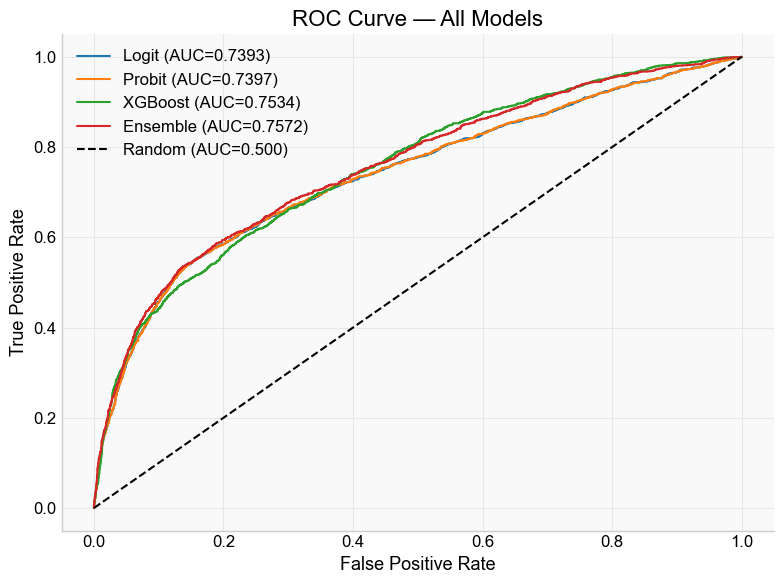


Ensemble Confusion Matrix:
[[5580  261]
 [1142  517]]

Default Recall: 0.312
Overall Accuracy: 0.813


In [31]:
# All predicted probabilities
ensemble_test = (1/3)*logit_test + (1/3)*probit_test + (1/3)*xgb_test

# Summary table 
models = {
    'Logit':    logit_test,
    'Probit':   probit_test,
    'XGBoost':  xgb_test,
    'Ensemble': ensemble_test
}

print("Model Performance Summary")
print("-" * 35)
for name, probs in models.items():
    auc = roc_auc_score(y_test, probs)
    print(f"{name:<20} AUC: {auc:.4f}")

# ROC curve all models 
plt.figure(figsize=(8,6))
for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.500)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix (ensemble) 
ensemble_pred = (ensemble_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, ensemble_pred)
print("\nEnsemble Confusion Matrix:")
print(cm)
print(f"\nDefault Recall: {cm[1,1]/(cm[1,0]+cm[1,1]):.3f}")
print(f"Overall Accuracy: {(cm[0,0]+cm[1,1])/len(y_test):.3f}")

In [39]:
# AIC and BIC (econometric models only)
print("Logit AIC:", round(logit_model.aic, 2))
print("Logit BIC:", round(logit_model.bic, 2))
print("Probit AIC:", round(probit_model.aic, 2))
print("Probit BIC:", round(probit_model.bic, 2))

print()

# Accuracy at 0.30 threshold (all models)
print("LPM Accuracy:",      accuracy_score(y_test, (lpm_model.predict(x_test) >= 0.30).astype(int)))
print("Logit Accuracy:",    accuracy_score(y_test, logit_pred))
print("Probit Accuracy:",   accuracy_score(y_test, probit_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(x_test_ml)))
print("XGBoost Accuracy:",  accuracy_score(y_test, xgb.predict(x_test_ml)))
print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))

Logit AIC: 20283.83
Logit BIC: 20388.11
Probit AIC: 20378.8
Probit BIC: 20483.08

LPM Accuracy: 0.7904
Logit Accuracy: 0.7949333333333334
Probit Accuracy: 0.7961333333333334
Random Forest Accuracy: 0.8073333333333333
XGBoost Accuracy: 0.8124
Ensemble Accuracy: 0.8129333333333333
